# 01 — Exploratory Data Analysis
LinkedIn Job Postings dataset: understanding salary distributions, feature relationships, and class balance.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid')
os.makedirs('../docs/figures', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

## 1. Load Data

In [4]:
df = pd.read_csv('../data/raw/postings.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (123849, 31)


,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


## 2. Basic Overview

In [6]:
df.info()
print('\nMissing values:')
print(df.isnull().sum().sort_values(ascending=False).head(20))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      123849 non-null  int64  
 1   company_name                122130 non-null  object 
 2   title                       123849 non-null  object 
 3   description                 123842 non-null  object 
 4   max_salary                  29793 non-null   float64
 5   pay_period                  36073 non-null   object 
 6   location                    123849 non-null  object 
 7   company_id                  122132 non-null  float64
 8   views                       122160 non-null  float64
 9   med_salary                  6280 non-null    float64
 10  min_salary                  29793 non-null   float64
 11  formatted_work_type         123849 non-null  object 
 12  applies                     23320 non-null   float64
 13  original_liste

In [7]:
df.describe()

,job_id,max_salary,company_id,views,med_salary,min_salary,applies,original_listed_time,remote_allowed,expiry,closed_time,listed_time,sponsored,normalized_salary,zip_code,fips
count,1.238490e+05,2.979300e+04,1.221320e+05,122160.000000,6280.000000,2.979300e+04,23320.000000,1.238490e+05,15246.0,1.238490e+05,1.073000e+03,1.238490e+05,123849.0,3.607300e+04,102977.000000,96434.000000
mean,3.896402e+09,9.193942e+04,1.220401e+07,14.618247,22015.619876,6.491085e+04,10.591981,1.713152e+12,1.0,1.716213e+12,1.712928e+12,1.713204e+12,0.0,2.053270e+05,50400.491887,28713.879887
std,8.404355e+07,7.011101e+05,2.554143e+07,85.903598,52255.873846,4.959738e+05,29.047395,4.848209e+08,0.0,2.321394e+09,3.622893e+08,3.989122e+08,0.0,5.097627e+06,30252.232515,16015.929825
min,9.217160e+05,1.000000e+00,1.009000e+03,1.000000,0.000000,1.000000e+00,1.000000,1.701811e+12,1.0,1.712903e+12,1.712346e+12,1.711317e+12,0.0,0.000000e+00,1001.000000,1003.000000
25%,3.894587e+09,4.828000e+01,1.435200e+04,3.000000,18.940000,3.700000e+01,1.000000,1.712863e+12,1.0,1.715481e+12,1.712670e+12,1.712886e+12,0.0,5.200000e+04,24112.000000,13121.000000
50%,3.901998e+09,8.000000e+04,2.269650e+05,4.000000,25.500000,6.000000e+04,3.000000,1.713395e+12,1.0,1.716042e+12,1.712670e+12,1.713408e+12,0.0,8.150000e+04,48059.000000,29183.000000
75%,3.904707e+09,1.400000e+05,8.047188e+06,8.000000,2510.500000,1.000000e+05,8.000000,1.713478e+12,1.0,1.716088e+12,1.713283e+12,1.713484e+12,0.0,1.250000e+05,78201.000000,42077.000000
max,3.906267e+09,1.200000e+08,1.034730e+08,9975.000000,750000.000000,8.500000e+07,967.000000,1.713573e+12,1.0,1.729125e+12,1.713562e+12,1.713573e+12,0.0,5.356000e+08,99901.000000,56045.000000


## 3. Create Target Variable — Salary Bands

In [9]:
# Drop rows missing salary info
df_salary = df.dropna(subset=['max_salary', 'min_salary']).copy()
print(f'Rows with salary info: {len(df_salary)} / {len(df)} ({len(df_salary)/len(df)*100:.1f}%)')

# Normalize to annual (check pay_period column)
print(df_salary['pay_period'].value_counts())

Rows with salary info: 29793 / 123849 (24.1%)
pay_period
YEARLY      19107
HOURLY      10212
MONTHLY       288
WEEKLY        177
BIWEEKLY        9
Name: count, dtype: int64


In [10]:
# Convert hourly to annual if needed
def normalize_salary(row):
    avg = (row['min_salary'] + row['max_salary']) / 2
    if str(row.get('pay_period', '')).upper() == 'HOURLY':
        return avg * 2080  # 40hrs * 52 weeks
    return avg

df_salary['salary_avg'] = df_salary.apply(normalize_salary, axis=1)

# Remove outliers (keep 5th–95th percentile)
low, high = df_salary['salary_avg'].quantile([0.05, 0.95])
df_salary = df_salary[(df_salary['salary_avg'] >= low) & (df_salary['salary_avg'] <= high)]
print(f'After outlier removal: {len(df_salary)} rows')
print(f'Salary range: ${low:,.0f} – ${high:,.0f}')

After outlier removal: 26866 rows
Salary range: $34,320 – $207,470


In [11]:
# Create salary bands
bins = [0, 50000, 90000, 140000, float('inf')]
labels = ['Low (<50k)', 'Mid (50–90k)', 'High (90–140k)', 'Very High (>140k)']
df_salary['salary_band'] = pd.cut(df_salary['salary_avg'], bins=bins, labels=labels)

print('\nSalary band distribution:')
print(df_salary['salary_band'].value_counts())


Salary band distribution:
salary_band
Mid (50–90k)         9762
High (90–140k)       8390
Very High (>140k)    4562
Low (<50k)           4152
Name: count, dtype: int64


## 4. Visualizations

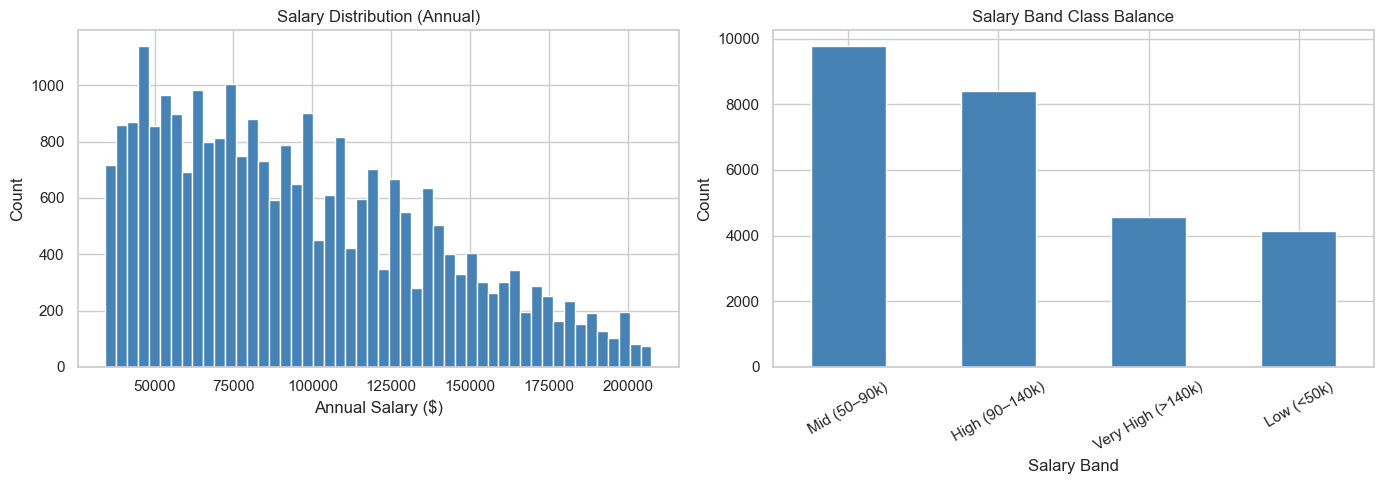

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Salary distribution
axes[0].hist(df_salary['salary_avg'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Salary Distribution (Annual)')
axes[0].set_xlabel('Annual Salary ($)')
axes[0].set_ylabel('Count')

# Class balance
df_salary['salary_band'].value_counts().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Salary Band Class Balance')
axes[1].set_xlabel('Salary Band')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../docs/figures/01_salary_distribution.png', dpi=150)
plt.show()

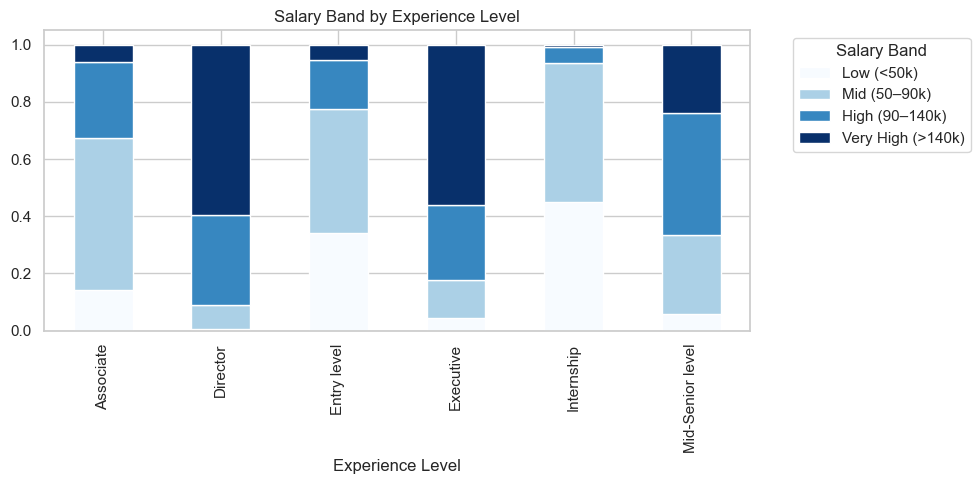

In [14]:
# Experience level vs salary band
if 'formatted_experience_level' in df_salary.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    ct = pd.crosstab(df_salary['formatted_experience_level'], df_salary['salary_band'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=ax, colormap='Blues')
    ax.set_title('Salary Band by Experience Level')
    ax.set_xlabel('Experience Level')
    ax.legend(title='Salary Band', bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.savefig('../docs/figures/02_experience_vs_salary.png', dpi=150)
    plt.show()

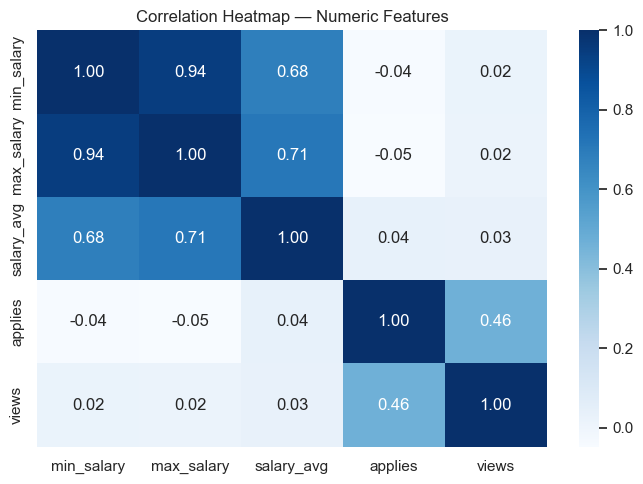

In [15]:
# Correlation heatmap
num_cols = ['min_salary', 'max_salary', 'salary_avg']
optional_cols = ['applies', 'views']
for c in optional_cols:
    if c in df_salary.columns:
        num_cols.append(c)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df_salary[num_cols].corr(), annot=True, fmt='.2f', cmap='Blues', ax=ax)
ax.set_title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.savefig('../docs/figures/03_correlation_heatmap.png', dpi=150)
plt.show()

## 5. Save Processed Dataset

In [17]:
cols_to_keep = ['title', 'description', 'salary_avg', 'salary_band',
                'formatted_experience_level', 'formatted_work_type',
                'location', 'company_id']
cols_available = [c for c in cols_to_keep if c in df_salary.columns]
df_clean = df_salary[cols_available].dropna(subset=['salary_band'])

df_clean.to_csv('../data/processed/job_postings_clean.csv', index=False)
print(f'Saved {len(df_clean)} rows to data/processed/job_postings_clean.csv')
df_clean.head()

Saved 26866 rows to data/processed/job_postings_clean.csv


,title,description,salary_avg,salary_band,formatted_experience_level,formatted_work_type,location,company_id
0,Marketing Coordinator,Job descriptionA leading real estate firm in N...,38480.0,Low (<50k),NaN,Full-time,"Princeton, NJ",2774458.0
1,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",83200.0,Mid (50–90k),NaN,Full-time,"Fort Collins, CO",NaN
2,Assitant Restaurant Manager,The National Exemplar is accepting application...,55000.0,Mid (50–90k),NaN,Full-time,"Cincinnati, OH",64896719.0
3,Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,157500.0,Very High (>140k),NaN,Full-time,"New Hyde Park, NY",766262.0
4,Service Technician,Looking for HVAC service tech with experience ...,70000.0,Mid (50–90k),NaN,Full-time,"Burlington, IA",NaN
